In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.0

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 0.1


## Exact Riemann solver

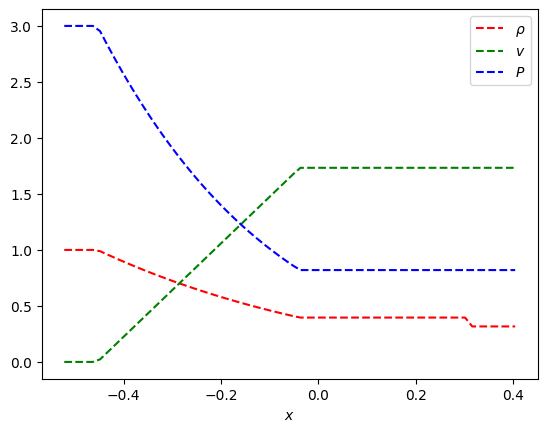

In [2]:
def exactsolution(L, ngrids, tout, rhoL, uL, pL, rhoR, uR, pR):
    global gamma,   gamma1, gamma2, gamma3, gamma4, gamma5
    #constants
    gamma = 1.4
    gamma1 = gamma + 1
    gamma2 = gamma -1
    gamma3 = gamma2/gamma1
    gamma4 = gamma2/(2*gamma)
    gamma5 = gamma1/(2*gamma)


    #box
    L = L
    ngrids = ngrids
    ghost = 2
    ntot = ngrids + 2*ghost
    dx = L/ntot
    


     
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR) 


    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)



    pstar, ustar, rhostarL, rhostarR = starfun(rhoL, uL, pL, rhoR, uR, pR)

    astarL = np.sqrt(gamma*pstar/rhostarL)
    astarR = np.sqrt(gamma*pstar/rhostarR) 


    for i in range(ntot):

        xpos = (i - 0.5)*dx
        s = (xpos - L/2)/tout

        if s < ustar:    

            if pL > pstar : # left fan

                sHL = uL - aL
                sTL = ustar - astarL

                if s < sHL:
                    rho[i] = rhoL
                    u[i] = uL
                    p[i] = pL
                elif s > sTL:
                    rho[i] = rhostarL
                    u[i] = ustar
                    p[i] = pstar
                else:
                    rho[i] = rhoL*(2/gamma1 + gamma2/(gamma1*aL)*(uL-s))**(2/gamma2)
                    u[i] = 2/gamma1*(aL + 0.5*gamma2*uL + s)
                    p[i] = pL*(2/gamma1 + gamma2/(gamma1*aL)*(uL-s))**(2*gamma/gamma2)


            else: # left shock

                sL = uL - aL*np.sqrt(gamma5*pstar/pL + gamma4)

                if s < sL:
                    rho[i] = rhoL
                    u[i] = uL
                    p[i] = pL
                else:
                    rho[i] = rhostarL
                    u[i] = ustar
                    p[i] = pstar


        else:

            if pR > pstar : # right fan

                sHR = uR + aR
                sTR = ustar + astarR

                if s > sHR:
                    rho[i] = rhoR
                    u[i] = uR
                    p[i] = pR
                elif s < sTR:
                    rho[i] = rhostarR
                    u[i] = ustar
                    p[i] = pstar
                else:
                    rho[i] = rhoR*(2/gamma1 - gamma2/(gamma1*aR)*(uR-s))**(2/gamma2)
                    u[i] = 2/gamma1*(-aR + 0.5*gamma2*uR + s)
                    p[i] = pR*(2/gamma1 - gamma2/(gamma1*aR)*(uR-s))**(2*gamma/gamma2)

            else: # right shock
                sR = uR + aR*(np.sqrt(gamma5*pstar/pR + gamma4))

                if s > sR:
                    rho[i] = rhoR
                    u[i] = uR
                    p[i] = pR
                else:
                    rho[i] = rhostarR
                    u[i] = ustar
                    p[i] = pstar
    return rho, u, p



                


def starfun(rhoL, uL, pL, rhoR, uR, pR):
    global gamma, gamma1, gamma2, gamma3, gamma4, gamma5

    quser = 2
    pmax = max(pL, pR)
    pmin = min(pL, pR)
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR)
    qmax = pmax/pmin

    cL = rhoL * aL
    cR = rhoR * aR
    ppv = (cL*pR + cR*pL - cL*cR*(uR-uL))/(cL+cR)
    #print("ppv", ppv)
    pstart = max(1e-6, ppv)

    ###     PVRS      ####
    if qmax < quser:
        pstart = pstart

    ###     TRRS      ####
    if pstart < pmin:
        pstart = pow(((aL + aR - 0.5*gamma2*(uR - uL)) / (aL/pow(pL, gamma4) + aR/pow(pR, gamma4))),1/gamma4)
        

    ###     TSRS      ####
    if pstart > pmax:
        ppvl  = max((0.5*(pL + pR) + 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        ppvr = max((0.5*(pL + pR) - 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        gL = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + ppvl))
        gR = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + ppvr))
        pstart = (gL*pL + gR*pR - (uR - uL)) / (gL + gR)

    
    for i in range(1,20):

        if pstart > pL: #shock
            fL = (pstart - pL)*np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))
            fld = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))*(1 - 0.5*(pstart - pL)/(gamma3*pL + pstart))
            
        else: #rarefaction
            fL =2*aL/gamma2 * (pow(pstart/pL, gamma4) - 1)
            fld = 1/(rhoL*aL)*pow(pstart/pL, -gamma5)

        if pstart > pR:
            fR = (pstart - pR)*np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))
            frd = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))*(1 - 0.5*(pstart - pR)/(gamma3*pR + pstart))

        else:
            fR = 2*aR/gamma2 * (pow(pstart/pR, gamma4) - 1)
            frd = 1/(rhoR*aR)*pow(pstart/pR, -gamma5)

        p = pstart - (fL + fR + uR - uL)/(fld + frd)
        
        p = max(p, 1e-6)

        cha = 2*abs(p - pstart)/(p + pstart)

        pstart = p

        if cha < 1e-6:
            break

    pstar = p

    if pstar > pL:
        fL = (pstar-pL)*np.sqrt(
             2/((gamma+1)*rhoL)/(gamma3*pL+pstar))
        rhostarL = rhoL*(pstar/pL + gamma3) / \
                   (gamma3*pstar/pL + 1)
    else:
        fL = 2*aL/gamma2*((pstar/pL)**gamma4 - 1)
        rhostarL = rhoL*(pstar/pL)**(1/gamma)

    if pstar > pR:
        fR = (pstar-pR)*np.sqrt(
             2/((gamma+1)*rhoR)/(gamma3*pR+pstar))
        rhostarR = rhoR*(pstar/pR + gamma3) / \
                   (gamma3*pstar/pR + 1)

    else:
        fR = 2*aR/gamma2*((pstar/pR)**gamma4 - 1)
        rhostarR = rhoR*(pstar/pR)**(1/gamma)    

    ustar = 0.5*(uL + uR) + 0.5*(fR - fL)

    return pstar, ustar, rhostarL, rhostarR




def plotexactsolution(L, ngrids, tout, rhoL, uL, pL, rhoR, uR, pR):

    celcenter = np.zeros(ngrids)
    L = L
    ngrids = ngrids
    ghost = 2
    ntot = ngrids + 2*ghost
    dx = L/ntot
    ist = ghost

    for i in range(ngrids):
        celcenter[i] = 0.5*(-L + (2*i-2*ist + 1)*dx)

    rho, u, p = exactsolution(L, ngrids, tout, rhoL, uL, pL, rhoR, uR, pR)

    plt.plot(celcenter, rho[2:-2],'--', color='red',label=r"$\rho$",)
    plt.plot(celcenter, u[2:-2],'--', color='green',label=r"$v$",)
    plt.plot(celcenter, p[2:-2],'--', color='blue',label=r"$P$")
    
    plt.xlabel(r'$x$')
    plt.legend()


plotexactsolution(L=1,ngrids=64, tout = 0.2,rhoL = 1.0 ,uL= 0.0, pL=3.0 ,rhoR=0.125 ,uR=0.0 ,pR=0.2)


## HLL

In [3]:
def prepareanimation_hll():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    plt.xlim(-0.5*1,0.5*1)
    plt.xlabel(r'$x$')

In [4]:
def addanimation_hll(cel_center, rho, u, p, legend,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout):

    global artistA
    
    im1 = plt.plot(cel_center, rho, color='red',label=r"$\rho$",)
    im2 = plt.plot(cel_center, u, color='green',label=r"$v$",)
    im3 = plt.plot(cel_center, p, color='blue',label=r"$P$")

    if legend == 1:
        rho_exact, u_exact, p_exact = exactsolution(rhoL=rhoL ,uL=velL, pL=preL ,rhoR=rhoR, uR=velR, pR=preR, L=L, ngrids=ngrids, tout=tout)
        plt.plot(cel_center, rho_exact,'--', label=r"$\rho_{exact}$",)
        plt.plot(cel_center, u_exact,'--',label=r"$v_{exact}$",)
        plt.plot(cel_center, p_exact,'--',label=r"$P_{exact}$")
    
    plt.xlabel(r'$x$')
    plt.xlim(min(cel_center), max(cel_center))
    #plt.ylim(-0.1, 1.2)
    
    if legend == 1:
        plt.legend()

    figA.tight_layout()
    
    artistA.append(im1 + im2 + im3)

In [8]:
def godunov_hll(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    
    for i in range(ist, ien-1):
        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] )

    return rho,mom,ene     

In [19]:
"""
def newtonraphson_hll(rhoL, uL, pL, rhoR, uR, pR):

    global gamma, gamma1, gamma2, gamma3, gamma4, gamma5

    quser = 2
    pmax = max(pL, pR)
    pmin = min(pL, pR)
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR)
    qmax = pmax/pmin

    cL = rhoL * aL
    cR = rhoR * aR
    ppv = (cL*pR + cR*pL - cL*cR*(uR-uL))/(cL+cR)
    #print("ppv", ppv)
    pstart = max(1e-6, ppv)

    ###     PVRS      ####
    if qmax < quser:
        pstart = pstart

    ###     TRRS      ####
    if pstart < pmin:
        pstart = pow(((aL + aR - 0.5*gamma2*(uR - uL)) / (aL/pow(pL, gamma4) + aR/pow(pR, gamma4))),1/gamma4)
        

    ###     TSRS      ####
    if pstart > pmax:
        ppvl  = max((0.5*(pL + pR) + 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        ppvr = max((0.5*(pL + pR) - 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        gL = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + ppvl))
        gR = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + ppvr))
        pstart = (gL*pL + gR*pR - (uR - uL)) / (gL + gR)

    
    for i in range(1,20):

        if pstart > pL: #shock
            fL = (pstart - pL)*np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))
            fld = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))*(1 - 0.5*(pstart - pL)/(gamma3*pL + pstart))
            
        else: #rarefaction
            fL =2*aL/gamma2 * (pow(pstart/pL, gamma4) - 1)
            fld = 1/(rhoL*aL)*pow(pstart/pL, -gamma5)

        if pstart > pR:
            fR = (pstart - pR)*np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))
            frd = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))*(1 - 0.5*(pstart - pR)/(gamma3*pR + pstart))

        else:
            fR = 2*aR/gamma2 * (pow(pstart/pR, gamma4) - 1)
            frd = 1/(rhoR*aR)*pow(pstart/pR, -gamma5)

        p = pstart - (fL + fR + uR - uL)/(fld + frd)
        
        p = max(p, 1e-6)

        cha = 2*abs(p - pstart)/(p + pstart)

        pstart = p

        if cha < 1e-6:
            break

    pstar = p
    
    delta = 10
    dp_Ldv=0
    dp_Rdv=0
    vL = 0
    vR = 0
    
    while abs(delta) > 1e-4:
        mass_flux_L = 0.5*cL**2*((gamma+1)*p_i/pL + (gamma -1))/gamma
        dp_Ldv = 2*mass_flux_L*np.sqrt(mass_flux_L)/(mass_flux_L + cL**2)
        
        mass_flux_R = 0.5*cR**2*((gamma+1)*p_i/pR + (gamma -1))/gamma
        dp_Rdv = 2*mass_flux_R*np.sqrt(mass_flux_R)/(mass_flux_R + cR**2)
        
        vL = uL - (p_i - pL)/np.sqrt(mass_flux_L)
        vR = uR + (p_i - pR)/np.sqrt(mass_flux_R) 

        delta = dp_Ldv* dp_Rdv*(vR - vL)/ ( (dp_Ldv + dp_Rdv)*p_i)
        p_i = p_i*(1.0 - delta)

    return p_i, (dp_Ldv*vL+ dp_Rdv*vR)/(dp_Ldv + dp_Rdv)
"""
def starfun_hll(rhoL, uL, pL, rhoR, uR, pR):

    global gamma, gamma1, gamma2, gamma3, gamma4, gamma5

    quser = 2
    pmax = max(pL, pR)
    pmin = min(pL, pR)
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR)
    qmax = pmax/pmin

    cL = rhoL * aL
    cR = rhoR * aR
    ppv = (cL*pR + cR*pL - cL*cR*(uR-uL))/(cL+cR)
    #print("ppv", ppv)
    pstart = max(1e-6, ppv)

    ###     PVRS      ####
    if qmax < quser:
        pstart = pstart

    ###     TRRS      ####
    if pstart < pmin:
        pstart = pow(((aL + aR - 0.5*gamma2*(uR - uL)) / (aL/pow(pL, gamma4) + aR/pow(pR, gamma4))),1/gamma4)
        

    ###     TSRS      ####
    if pstart > pmax:
        ppvl  = max((0.5*(pL + pR) + 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        ppvr = max((0.5*(pL + pR) - 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        gL = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + ppvl))
        gR = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + ppvr))
        pstart = (gL*pL + gR*pR - (uR - uL)) / (gL + gR)

    
    for i in range(1,20):

        if pstart > pL: #shock
            fL = (pstart - pL)*np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))
            fld = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))*(1 - 0.5*(pstart - pL)/(gamma3*pL + pstart))
            
        else: #rarefaction
            fL =2*aL/gamma2 * (pow(pstart/pL, gamma4) - 1)
            fld = 1/(rhoL*aL)*pow(pstart/pL, -gamma5)

        if pstart > pR:
            fR = (pstart - pR)*np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))
            frd = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))*(1 - 0.5*(pstart - pR)/(gamma3*pR + pstart))

        else:
            fR = 2*aR/gamma2 * (pow(pstart/pR, gamma4) - 1)
            frd = 1/(rhoR*aR)*pow(pstart/pR, -gamma5)

        p = pstart - (fL + fR + uR - uL)/(fld + frd)
        
        p = max(p, 1e-6)

        cha = 2*abs(p - pstart)/(p + pstart)

        pstart = p

        if cha < 1e-6:
            break

    pstar = p
    
    if pstar > pL:
        fL = (pstar-pL)*np.sqrt(
             2/((gamma+1)*rhoL)/(gamma3*pL+pstar))
        rhostarL = rhoL*(pstar/pL + gamma3) / \
                   (gamma3*pstar/pL + 1)
    else:
        fL = 2*aL/gamma2*((pstar/pL)**gamma4 - 1)
        rhostarL = rhoL*(pstar/pL)**(1/gamma)

    if pstar > pR:
        fR = (pstar-pR)*np.sqrt(
             2/((gamma+1)*rhoR)/(gamma3*pR+pstar))
        rhostarR = rhoR*(pstar/pR + gamma3) / \
                   (gamma3*pstar/pR + 1)

    else:
        fR = 2*aR/gamma2*((pstar/pR)**gamma4 - 1)
        rhostarR = rhoR*(pstar/pR)**(1/gamma)    

    ustar = 0.5*(uL + uR) + 0.5*(fR - fL)

    return pstar, ustar, rhostarL, rhostarR

In [30]:
def hll(rhoL, uL, pL, rhoR, uR, pR):

    global gamma

    rhoL = rhoL
    uL = uL
    pL = pL 

    rhoR = rhoR
    uR = uR
    pR = pR

    gamma = 1.4
   
    s = np.zeros(3)

    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)

    #p_star, v_star = newtonraphson_hll(rhoL, uL, pL, rhoR, uR, pR)
    p_star, v_star, rhostarL, rhostarR = starfun_hll(rhoL, uL, pL, rhoR, uR, pR)

    if p_star > pL: #shock

        s[0] = uL - aL*np.sqrt( ( (gamma + 1)*p_star/pL + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction
        s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rhostarL) )
        #s[0] = uL -aL

    if p_star > pR: #shock
        s[2] = uR + aR*np.sqrt( ( (gamma + 1)*p_star/pR + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction

        s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rhostarR) )
        #s[2] = uR + aR
    
    s[1] = v_star
    #s[1] = (pR - pL+ rhoL*uL*(s[0] - uL) - rhoR*uR*(s[2] - uR))/(rhoL*(s[0] - uL) - rhoR*(s[2] - uR))


    if s[0] > 0: #wL
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL

        
    elif s[0]<=0 and s[2] >= 0: #w*
        frho =  (s[2]*rhoL * uL - s[0]*rhoR * uR + s[2]*s[0]*(rhoR - rhoL))/(s[2]-s[0])
        fmom= (s[2]*(rhoL * uL**2 + pL) - s[0]*(rhoR * uR**2 + pR) + s[2]*s[0]*(rhoR*uR - rhoL*uL))/(s[2]-s[0])
        fe = (s[2]*(gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL - s[0]*(gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR + s[2]*s[0]*(pR/(gamma-1)+ 0.5*rhoR*uR**2 - pL/(gamma-1)+ 0.5*rhoL*uL**2))/(s[2]-s[0])
           
    else:  #wR
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR

    return frho, fmom, fe

In [18]:
def shocktube1d_hll(rhoL,velL,preL,rhoR,velR,preR,L,ngrids,cfl,tout):
    
    global ist, ien, dx, ntot, gamma, gamma1, gamma2, gamma3, gamma4, gamma5

    #constants
    gamma = 1.4
    gamma1 = gamma + 1
    gamma2 = gamma -1
    gamma3 = gamma2/gamma1
    gamma4 = gamma2/(2*gamma)
    gamma5 = gamma1/(2*gamma)

    #initial conditions
    rhoL = rhoL 
    uL = velL
    pL = preL

    rhoR = rhoR
    uR = velR
    pR = preR

    dx = L / ngrids
    cfl = 0.9
     
    ist = 2
    nghost = ist
    ien = ngrids + nghost
    ntot = ngrids + 2*nghost
    cfl = 0.5

    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)

    #fluxes
    global frho, frhou, fe
    frho = np.zeros(ntot)
    fmom = np.zeros(ntot)
    fe = np.zeros(ntot)

    mom = np.zeros(ntot)
    ene = np.zeros(ntot)

    time = 0
    dt_plot = 0.01


    prepareanimation_hll()


    cel_center = np.zeros(ntot)
    cel_boundary = np.zeros(ntot+1)

    for i in range(ntot +1):
        cel_boundary[i] = -0.5*L + (i-ist)*dx

    for i in range(ntot):
        cel_center[i] = 0.5*(cel_boundary[i] + cel_boundary[i+1])


    for i in range(ntot):
        
        rho[i] = (rhoR - rhoL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + rhoL
        u[i] = (velR - velL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + velL
        p[i] = (preR - preL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + preL

        mom[i] = rho[i]*u[i]
        ene[i] = p[i]/(gamma-1) + 0.5*rho[i]*u[i]**2    

            
    addanimation_hll(cel_center, rho, u, p,1,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)


    rhoL = np.zeros(ntot)   
    rhoR = np.zeros(ntot)  
    uL = np.zeros(ntot) 
    uR = np.zeros(ntot)   
    pL = np.zeros(ntot)  
    pR = np.zeros(ntot)   


    dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
    

    time_plot = 0

    while time < tout:
        
            # calculate w_{i+1/2,L}
        for i in range(ist-1,ien):
            rhoL[i] = rho[i]
            uL[i] = u[i]
            pL[i] = p[i]

        # calculate u_{i+1/2,R}
        for i in range(ist-1,ien):
            rhoR[i] = rho[i+1]
            uR[i] = u[i+1]
            pR[i] = p[i+1]

        for i in range(ist-1, ien):
            frho[i], fmom[i], fe[i] = hll(rhoL[i], uL[i], pL[i], rhoR[i], uR[i], pR[i])
        
        rho, mom, ene = godunov_hll(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe)

        for i in range(ist, ien):
            u[i] = mom[i]/rho[i]
            p[i] = (gamma-1)*(ene[i] - 0.5*rho[i]*u[i]**2)  #(ene[i] - 0.5*mom[i]*u[i])/rho[i]
        
        time = time + dt
        time_plot = time_plot + dt
        
        if time_plot > dt_plot:
            addanimation_hll(cel_center, rho, u, p,0,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)
            time_plot = 0.0

        dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
        
        if  time + dt > tout:
            dt = tout - time
        
    addanimation_hll(cel_center, rho, u, p,0,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)


if __name__ == "__main__":
    shocktube1d_hll(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=0.1,L=1.0,ngrids=64,cfl=0.2,tout=0.20)
anim = ArtistAnimation(figA, artistA, interval=100) 
plt.close(figA) 
HTML(anim.to_jshtml())
 

/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_1595/969246189.py:22: UserWarning: The figure layout has changed to tight
  figA.tight_layout()


## HLLC

In [22]:
def prepareanimation_hllc():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    #plt.xlim(-0.5*1,0.5*1)
    plt.xlabel(r'$x$')

In [23]:
def addanimation_hllc(cel_center, rho, u, p, legend,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout):

    global artistA
    
    im1 = plt.plot(cel_center, rho, color='red',label=r"$\rho_{HLLC}$",)
    im2 = plt.plot(cel_center, u, color='green',label=r"$v_{HLLC}$",)
    im3 = plt.plot(cel_center, p, color='blue',label=r"$P_{HLLC}$")

    if legend == 1:
        rho_exact, u_exact, p_exact = exactsolution(rhoL=rhoL ,uL=velL, pL=preL ,rhoR=rhoR, uR=velR, pR=preR, L=L, ngrids=ngrids, tout=tout)
        plt.plot(cel_center, rho_exact,'--', label=r"$\rho_{exact}$",)
        plt.plot(cel_center, u_exact,'--',label=r"$v_{exact}$",)
        plt.plot(cel_center, p_exact,'--',label=r"$P_{exact}$")
    
    plt.xlabel(r'$x$')
    plt.xlim(min(cel_center), max(cel_center))
    
    if legend == 1:
        plt.legend()

    figA.tight_layout()
    
    artistA.append(im1 + im2 + im3)

In [24]:
def godunov_hllc(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    #print(len(frho))
    
    for i in range(ist, ien):

        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] ) 

    return rho,mom,ene 

In [25]:
"""
def newtonraphson_hllc(uL, uR, pR, pL, cL, cR):
    global gamma
    ## vL(p)=vR(p)
    #f(p) = vL(p) - vR(p)
    gamma = 1.4

    p_i = ( cR*pL + cL*pR - cR*cL*(uR - uL) )/(cR + cL)
    
    if p_i<0:p_i = 1e-8
    
    delta = 10
    dp_Ldv=0
    dp_Rdv=0
    vL = 0
    vR = 0
    
    while abs(delta) > 1e-4:
        mass_flux_L = 0.5*cL**2*((gamma+1)*p_i/pL + (gamma -1))/gamma
        dp_Ldv = 2*mass_flux_L*np.sqrt(mass_flux_L)/(mass_flux_L + cL**2)
        
        mass_flux_R = 0.5*cR**2*((gamma+1)*p_i/pR + (gamma -1))/gamma
        dp_Rdv = 2*mass_flux_R*np.sqrt(mass_flux_R)/(mass_flux_R + cR**2)
        
        vL = uL - (p_i - pL)/np.sqrt(mass_flux_L)
        vR = uR + (p_i - pR)/np.sqrt(mass_flux_R) 

        delta = dp_Ldv* dp_Rdv*(vR - vL)/ ( (dp_Ldv + dp_Rdv)*p_i)
        p_i = p_i*(1.0 - delta)

    return p_i, (dp_Ldv*vL+ dp_Rdv*vR)/(dp_Ldv + dp_Rdv)
"""    

def starfun(rhoL, uL, pL, rhoR, uR, pR):

    global gamma, gamma1, gamma2, gamma3, gamma4, gamma5

    quser = 2
    pmax = max(pL, pR)
    pmin = min(pL, pR)
    aL = np.sqrt(gamma*pL/rhoL)
    aR = np.sqrt(gamma*pR/rhoR)
    qmax = pmax/pmin

    cL = rhoL * aL
    cR = rhoR * aR
    ppv = (cL*pR + cR*pL - cL*cR*(uR-uL))/(cL+cR)
    #print("ppv", ppv)
    pstart = max(1e-6, ppv)

    ###     PVRS      ####
    if qmax < quser:
        pstart = pstart

    ###     TRRS      ####
    if pstart < pmin:
        pstart = pow(((aL + aR - 0.5*gamma2*(uR - uL)) / (aL/pow(pL, gamma4) + aR/pow(pR, gamma4))),1/gamma4)
        

    ###     TSRS      ####
    if pstart > pmax:
        ppvl  = max((0.5*(pL + pR) + 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        ppvr = max((0.5*(pL + pR) - 0.5*(uR - uL)*0.25*(rhoL + rhoR)*(aL + aR), 1e-6))
        gL = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + ppvl))
        gR = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + ppvr))
        pstart = (gL*pL + gR*pR - (uR - uL)) / (gL + gR)

    
    for i in range(1,20):

        if pstart > pL: #shock
            fL = (pstart - pL)*np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))
            fld = np.sqrt(2/(gamma1*rhoL) * 1/(gamma3*pL + pstart))*(1 - 0.5*(pstart - pL)/(gamma3*pL + pstart))
            
        else: #rarefaction
            fL =2*aL/gamma2 * (pow(pstart/pL, gamma4) - 1)
            fld = 1/(rhoL*aL)*pow(pstart/pL, -gamma5)

        if pstart > pR:
            fR = (pstart - pR)*np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))
            frd = np.sqrt(2/(gamma1*rhoR) * 1/(gamma3*pR + pstart))*(1 - 0.5*(pstart - pR)/(gamma3*pR + pstart))

        else:
            fR = 2*aR/gamma2 * (pow(pstart/pR, gamma4) - 1)
            frd = 1/(rhoR*aR)*pow(pstart/pR, -gamma5)

        p = pstart - (fL + fR + uR - uL)/(fld + frd)
        
        p = max(p, 1e-6)

        cha = 2*abs(p - pstart)/(p + pstart)

        pstart = p

        if cha < 1e-6:
            break

    pstar = p
    if pstar > pL:
        fL = (pstar-pL)*np.sqrt(
             2/((gamma+1)*rhoL)/(gamma3*pL+pstar))
        rhostarL = rhoL*(pstar/pL + gamma3) / \
                   (gamma3*pstar/pL + 1)
    else:
        fL = 2*aL/gamma2*((pstar/pL)**gamma4 - 1)
        rhostarL = rhoL*(pstar/pL)**(1/gamma)

    if pstar > pR:
        fR = (pstar-pR)*np.sqrt(
             2/((gamma+1)*rhoR)/(gamma3*pR+pstar))
        rhostarR = rhoR*(pstar/pR + gamma3) / \
                   (gamma3*pstar/pR + 1)

    else:
        fR = 2*aR/gamma2*((pstar/pR)**gamma4 - 1)
        rhostarR = rhoR*(pstar/pR)**(1/gamma)    

    ustar = 0.5*(uL + uR) + 0.5*(fR - fL)

    return pstar, ustar, rhostarL, rhostarR

In [31]:
def hllc(rhoL, uL, pL, rhoR, uR, pR):

    global gamma

    rhoL = rhoL
    uL = uL
    pL = pL 

    rhoR = rhoR
    uR = uR
    pR = pR

    gamma = 1.4
   
    s = np.zeros(3)

    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)
     
    #p_star, v_star = newtonraphson_hllc(uL, uR, pR, pL, aL, aR)
    p_star, v_star, rho_star_l, rho_star_r = starfun(rhoL, uL, pL, rhoR, uR, pR)
    
    
    if p_star >= pL: #shock
        #rho_star_l = rhoL*(p_star/pL + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pL + 1.0)
        s[0] = uL - aL*np.sqrt( ( (gamma + 1)*p_star/pL + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction
        #rho_star_l = rhoL * (p_star/pL)**(1/gamma)
        s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rho_star_l) )
        

    if p_star >= pR: #shock
        #rho_star_r = rhoR*(p_star/pR + (gamma-1)/(gamma+1))/( (gamma-1)/(gamma+1)*p_star/pR + 1.0)
        s[2] = uR + aR*np.sqrt( ( (gamma + 1)*p_star/pR + (gamma+1) )/(2.0*gamma) )
        
    else: #rarefaction
        #rho_star_r = rhoR * (p_star/pR)**(1/gamma)
        s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rho_star_r) )
        


    #s[0] = min(uL - np.sqrt(gamma*pL/rhoL), uR - np.sqrt(gamma*pR/rhoR))
    #s[2] = max(uL + np.sqrt(gamma*pL/rhoL), uR + np.sqrt(gamma*pR/rhoR))

    
    s[1] = v_star
    #s[1] = (pR - pL+ rhoL*uL*(s[0] - uL) - rhoR*uR*(s[2] - uR))/(rhoL*(s[0] - uL) - rhoR*(s[2] - uR))

    if s[0] >= 0: #wL
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL

    elif s[1] >= 0: #wL*
        """
        frho =  rho_star_l * v_star
        fmom= rho_star_l * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_l*v_star**2) * v_star
        """
        frho = (s[1]*(s[0]*rhoL - rhoL*uL)) / (s[0] - s[1])
        fmom = (s[1]*(s[0]*rhoL*uL - (rhoL * uL**2 + pL)) + s[0]*(pL + rhoL*(s[0] - uL)*(s[1] - uL)))/(s[0] - s[1])
        fe =  (s[1]*(s[0]*(pL/(gamma-1) + 0.5*rhoL*uL**2) - (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2) * uL) + s[0]*(pL+ rhoL*(s[0] - uL)*(s[1] - uL))*s[1])/(s[0] - s[1])

    elif s[2] >= 0: #wR*
        frho =  rho_star_r * v_star
        fmom= rho_star_r * v_star**2 + p_star
        fe = (gamma*p_star/(gamma-1) + 0.5*rho_star_r*v_star**2) * v_star

    else:  #wR
        """
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR
        """
        frho = (s[1]*(s[2]*rhoR - rhoR*uR)) / (s[2] - s[1])
        fmom = (s[1]*(s[2]*rhoR*uR - (rhoR * uR**2 + pR)) + s[2]*(pR + rhoR*(s[2] - uR)*(s[1] - uR)))/(s[2] - s[1])
        fe =  (s[1]*(s[2]*(pR/(gamma-1) + 0.5*rhoR*uR**2) - (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2) * uR) + s[2]*(pR+ rhoR*(s[2] - uR)*(s[1] - uR))*s[1])/(s[2] - s[1])

    return frho, fmom, fe

In [32]:
def shocktube1d_hllc(rhoL,velL,preL,rhoR,velR,preR,L,ngrids,cfl,tout):
    
    global ist, ien, dx, ntot, gamma

    #initial conditions
    dL = rhoL 
    uL = velL
    pL = preL

    dR = rhoR
    uR = velR
    pR = preR

    dx = L / ngrids
    gamma = 1.4
     
    ist = 2
    nghost = ist
    ien = ngrids + nghost
    ntot = ngrids + 2*nghost

    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)

    #fluxes
    global frho, frhou, fe
    frho = np.zeros(ntot)
    fmom = np.zeros(ntot)
    fe = np.zeros(ntot)

    mom = np.zeros(ntot)
    ene = np.zeros(ntot)

    time = 0
   
    prepareanimation_hllc()


    cel_center = np.zeros(ntot)
    cel_boundary = np.zeros(ntot+1)

    for i in range(ntot +1):
        cel_boundary[i] = -0.5*L + (i-ist)*dx #(i - ist) * dx

    for i in range(ntot):
        cel_center[i] = 0.5*(cel_boundary[i] + cel_boundary[i+1])


    for i in range(ntot):
        
        rho[i] = (dR - dL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + dL
        u[i] = (uR - uL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + uL
        p[i] = (pR - pL)*0.5*( np.tanh(cel_center[i]/(1.0*dx)) + 1.0) + pL

        mom[i] = rho[i]*u[i]
        ene[i] = p[i]/(gamma-1) + 0.5*rho[i]*u[i]**2 

               
    addanimation_hllc(cel_center, rho, u, p,1,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)


    dL = np.zeros(ntot)   
    dR = np.zeros(ntot)  
    uL = np.zeros(ntot) 
    uR = np.zeros(ntot)   
    pL = np.zeros(ntot)  
    pR = np.zeros(ntot)   


    dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
    

    time_plot = 0
    dt_plot = 0.01

    while time < tout:
        
        # calculate w_{i+1/2,L}
        for i in range(ist-1,ien):
            dL[i] = rho[i]
            uL[i] = u[i]
            pL[i] = p[i]

        # calculate u_{i+1/2,R}
        for i in range(ist-1,ien):
            dR[i] = rho[i+1]
            uR[i] = u[i+1]
            pR[i] = p[i+1]

        for i in range(ist-1, ien):
            frho[i], fmom[i], fe[i] = hllc(dL[i], uL[i], pL[i], dR[i], uR[i], pR[i])
        
        rho, mom, ene = godunov_hllc(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe)

        for i in range(ist, ien):
            u[i] = mom[i]/rho[i]
            p[i] = (gamma-1)*(ene[i] - 0.5*rho[i]*u[i]**2)  #(ene[i] - 0.5*mom[i]*u[i])/rho[i]
        
        time = time + dt
        time_plot = time_plot + dt
        
        if time_plot > dt_plot:
            addanimation_hllc(cel_center, rho, u, p,0,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)
            time_plot = 0.0

        dt = cfl*np.min(dx/(np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien])))
        
        if  time + dt > tout:
            dt = tout - time
        
    addanimation_hllc(cel_center, rho, u, p,0,rhoL ,velL, preL ,rhoR, velR,preR,L,ngrids,tout)



shocktube1d_hllc(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=0.1,L=1,ngrids=64,cfl=0.2,tout=0.2)

anim = ArtistAnimation(figA, artistA, interval=100) 
plt.close(figA) 
HTML(anim.to_jshtml())
 

/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_1595/2261838335.py:21: UserWarning: The figure layout has changed to tight
  figA.tight_layout()


Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 0.1

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 1.0


In [ ]:
shocktube1d_hllc(rhoL = 1.0 ,velL= 0.0, preL=0.1 ,rhoR=0.125 ,velR=0.0 ,preR=1.0,L=1,ngrids=64,cfl=0.2,tout=0.2)

anim = ArtistAnimation(figA, artistA, interval=100) 
plt.close(figA) 
HTML(anim.to_jshtml())

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.0

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 1.0


In [ ]:
shocktube1d_hllc(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=1.0, L=1, ngrids=64, cfl=0.2, tout=0.2)

anim = ArtistAnimation(figA, artistA, interval=100) 
plt.close(figA) 
HTML(anim.to_jshtml())

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.2

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 1.0


In [ ]:
shocktube1d_hllc(rhoL = 1.0 ,velL= 0.0, preL=1.5 ,rhoR=0.125 ,velR=0.0 ,preR=1.0, L=1, ngrids=64, cfl=0.2, tout=0.2)

anim = ArtistAnimation(figA, artistA, interval=100) 
plt.close(figA) 
HTML(anim.to_jshtml())